# Business Problem  
The notebook details a statistical analysis and hypothesis testing process exploring player interactions with a puzzle game, as well as a corralation study of biometric dataset



# Research question  
### hypothesis test 1:   
Check if time to solve puzzle word is the same time to solve puzzle logic (ttest)( see game_data.csv).  
### hypothesis test 2:   
 Check if experience rating is independant from puzzle type (chi-square)(data_game.csv).
### non parametric test 1:  
Check if time to solve puzzle word is the same time to solve puzzle logic (ttest)( see game_data_np.csv).
### non parametric test 2:  
 test if experience rating is independant from puzzle type.
### correlation (vitals.csv):  
 correlation between height and weight.

# importing libraries


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from statsmodels.stats.power import TTestIndPower
from scipy import stats

# Data description

### "game_data.csv"  


The dataset contains 6,000 records representing player interactions with a puzzle game. It is completely clean, with no missing values across any of its rows.  

The file consists of three columns tracking the type of challenge, performance, and user feedback:

__PuzzleType (Text)__: The category of the puzzle played. The dataset is perfectly balanced between two types:
Word: 3,000 records
Logic: 3,000 records

__TimeToSolve__ (Numeric - Float): The time taken by the player to complete the puzzle (likely measured in seconds or minutes).

__ExperienceRating__ (Text): The subjective feedback provided by the player after finishing the puzzle. It contains three distinct categories:
Neutral: 3,511 records (Most frequent)
Fun
Frustrating

### " game_data_np.csv"

The dataset contains 1,600 records representing user performance and subjective feedback for a puzzle game., with no missing values across any of its rows.  

The file consists of three columns tracking the type of challenge, performance, and user feedback:

__PuzzleType (Text)__: Same column above :  
Word: 800 records  
Logic: 800 records

__TimeToSolve__ (Numeric - Float): The time taken by the player to complete the puzzle (likely measured in seconds or minutes).
 
__isFun__ : A binary yes/no indicator representing whether the player found the puzzle fun  
Yes: 875   
No: 725

### " vitals.csv"

The dataset contains biometric measurements and gender classification for individuals.  
The file consists of three columns tracking height, weight and gender

## EDA


In [3]:
game_data = pd.read_csv("game_data.csv")
game_data.head()
game_data.shape
game_data.info()
game_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PuzzleType        6000 non-null   str    
 1   TimeToSolve       6000 non-null   float64
 2   ExperienceRating  6000 non-null   str    
dtypes: float64(1), str(2)
memory usage: 140.8 KB


,TimeToSolve
count,6000.000000
mean,11.260462
std,2.130144
min,3.980000
25%,9.830000
50%,11.280000
75%,12.700000
max,18.840000


In [4]:
game_data_np = pd.read_csv("game_data_np.csv")
game_data_np.head()
game_data_np.shape
game_data_np.info()
game_data_np.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PuzzleType   1600 non-null   str    
 1   TimeToSolve  1600 non-null   float64
 2   isFun        1600 non-null   str    
dtypes: float64(1), str(2)
memory usage: 37.6 KB


,TimeToSolve
count,1600.000000
mean,37.600244
std,7.983147
min,5.500000
25%,33.100000
50%,36.875000
75%,44.892500
max,49.260000


In [11]:
vitals = pd.read_csv("vitals.csv")
vitals.head()
vitals.shape
vitals.info()
vitals.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  500 non-null    float64
 1   Weight  500 non-null    float64
 2   Gender  500 non-null    str    
dtypes: float64(2), str(1)
memory usage: 11.8 KB


,Height,Weight
count,500.000000,500.000000
mean,0.033554,0.032077
std,0.992214,0.960833
min,-2.854289,-3.037250
25%,-0.659584,-0.554869
50%,0.029120,0.010200
75%,0.696538,0.647579
max,3.083700,3.065741


### hypothesis test 1:  
Check if time to solve puzzle word is the same time to solve puzzle logic (ttest)( see game_data.csv)


### plot to figure out:

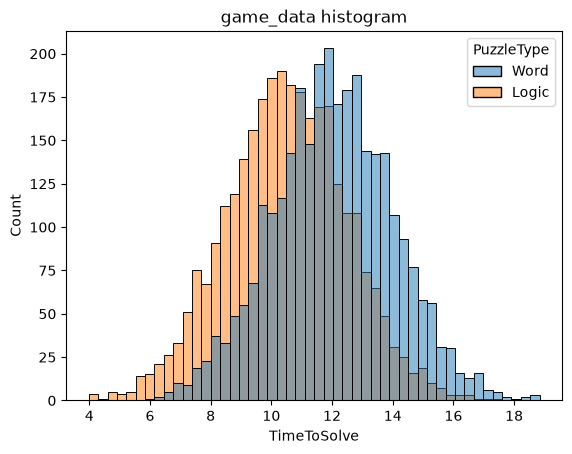

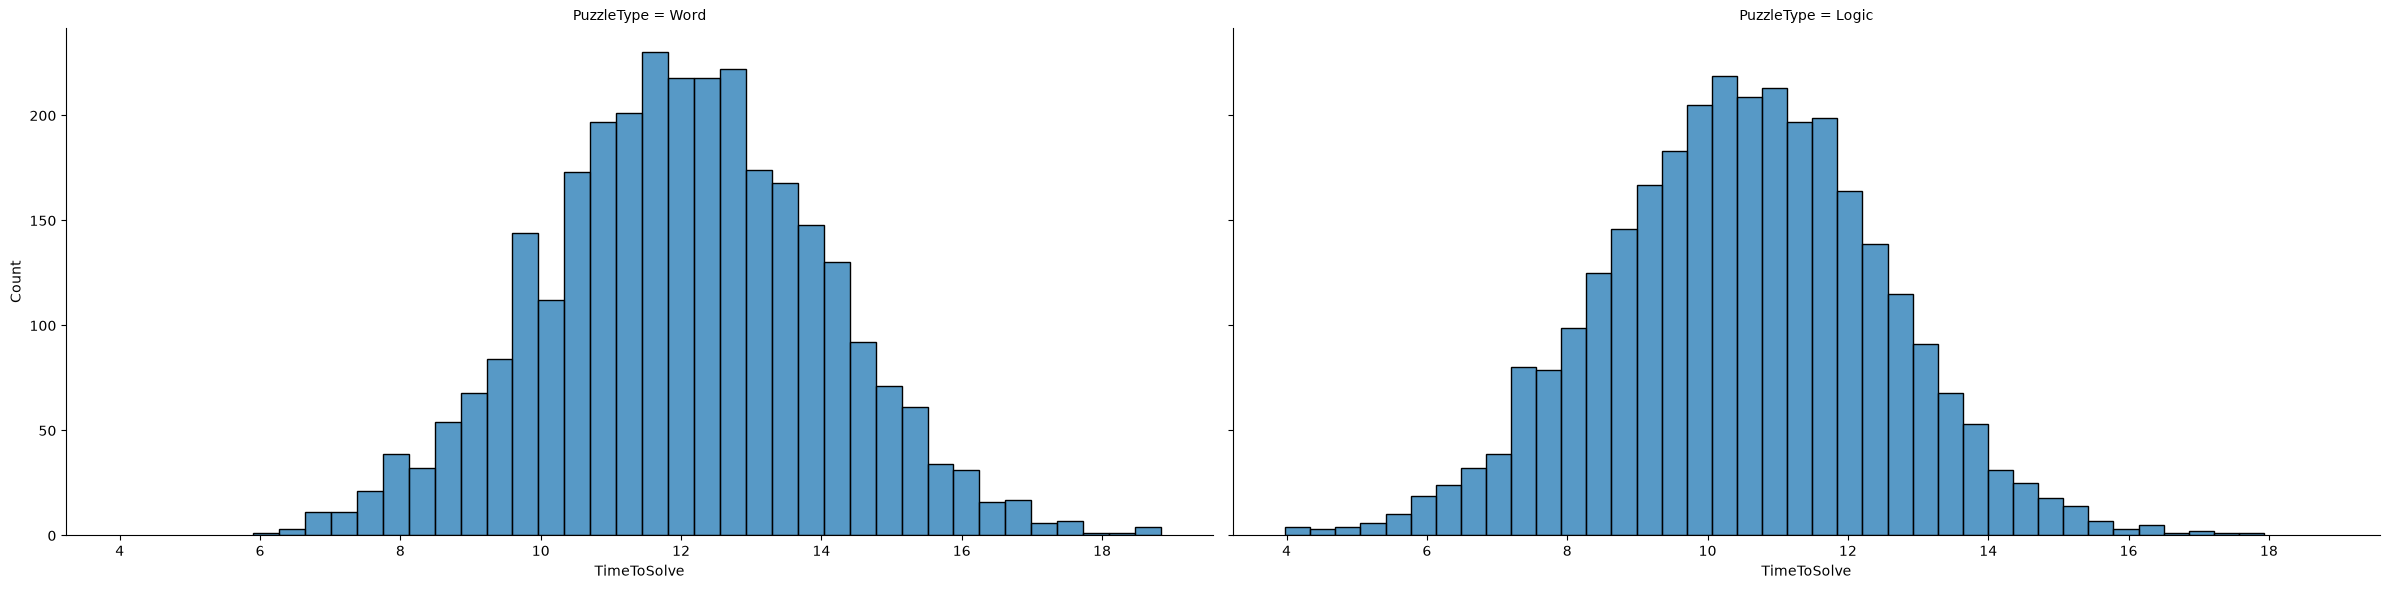

In [6]:
sns.histplot(data = game_data, x= "TimeToSolve", hue = "PuzzleType")
plt.title("game_data histogram")
plt.show()

hist1 = sns.FacetGrid(game_data, col = "PuzzleType", height = 6, aspect=2)
hist1.map(sns.histplot,  "TimeToSolve")
plt.show()

__1- check asumption__ 

__Normality of distribution__

In [7]:
group_w = game_data[game_data["PuzzleType"] == "Word"]["TimeToSolve"]
group_l = game_data[game_data["PuzzleType"] == "Logic"]["TimeToSolve"]

statistic_w, p_w = stats.shapiro(group_w)
print(f"p_w = {p_w}")
statistic_l, p_l = stats.shapiro(group_l)
print(f"p_l = {p_l}")
print(game_data.shape)

p_w = 0.39269487550930815
p_l = 0.7417297781568364
(6000, 3)


the p_l( the p value of the distribution TimeToSolve is greater than 0.05), the normality of distribution is respested
the p_w( the p value of the distribution TimeToSolve is greater than 0.05), the normality of distribution is respested

__Homoscedasticity__

In [8]:
levene_result = pg.homoscedasticity(data = game_data ,dv = "TimeToSolve", group = "PuzzleType", method = 'levene')
print(levene_result)


               W      pval  equal_var
levene  0.000052  0.994258       True


pval is greater than 0.05 homoscedasticity is respected.

__sample size (power test)__

In [9]:
analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size= 0.8, power=0.8, alpha =0.05)
print(sample_size)
power = pg.power_ttest(d=0.8, n=25, alpha =0.05)
print(power)

25.524571854446116
0.7914512899851559


the sample size needed to procede a ttest is 25
79% of chance there is a difference between time to solve puzzle word and time to solve puzzle logic

__hypothesis_test 1 (ttest):__

In [10]:
ttest_result =pg.ttest(group_w, group_l, paired = True, alternative = "two-sided")
print(ttest_result)

                T   dof alternative          p_val          CI95   cohen_d  \
T_test  30.097942  2999   two-sided  3.887446e-174  [1.43, 1.63]  0.769724   

        power        BF10  
T_test    1.0  1.139e+170  


p_val is less than 0.05 there is a difference difference between time to solve puzzle word and time to solve puzzle logic  
cohen_d 0.79 the difference is strong  
power 100% with a big dataset 3000

### hypothesis test 2:  
Check if experience rating is independant from puzzle type (chi-square)(data_game.csv)

### plot to figure out:

ExperienceRating  Frustrating   Fun  Neutral
PuzzleType                                  
Logic                     132  1114     1754
Word                      147  1096     1757


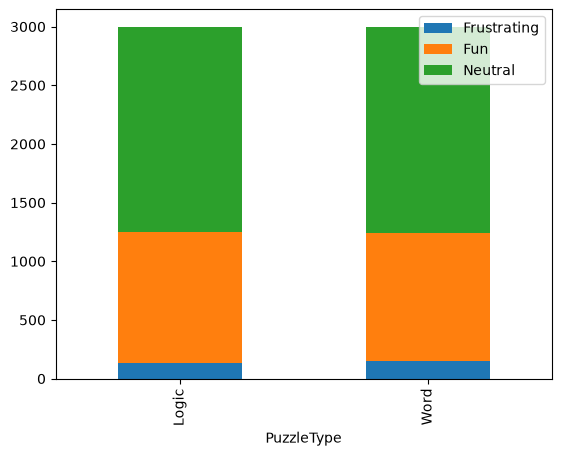

In [11]:
f_table = pd.crosstab(game_data["PuzzleType"], game_data["ExperienceRating"])
print(f_table)
f_table.plot(kind = 'bar', stacked= True)
plt.legend(loc = 'upper right')
plt.show()

__hypothesis_test 2 (chi-square):__

In [12]:
expected, observed,stats = pg.chi2_independence(data = game_data, x = 'PuzzleType', y = 'ExperienceRating')
print(stats)

                 test    lambda      chi2  dof      pval    cramer     power
0             pearson  1.000000  0.955621  2.0  0.620140  0.012620  0.128767
1        cressie-read  0.666667  0.955708  2.0  0.620113  0.012621  0.128774
2      log-likelihood  0.000000  0.956012  2.0  0.620019  0.012623  0.128801
3       freeman-tukey -0.500000  0.956354  2.0  0.619912  0.012625  0.128832
4  mod-log-likelihood -1.000000  0.956794  2.0  0.619776  0.012628  0.128871
5              neyman -2.000000  0.957969  2.0  0.619412  0.012636  0.128975


p values are greater than 0.05 rating is independant from puzzle type.

__power test:__

In [13]:
from statsmodels.stats.power import GofChisquarePower
analysis = GofChisquarePower()
sample_size = analysis.solve_power(effect_size= 0.1, power=0.8, alpha =0.05)
print(f"sample_size = {sample_size}")
power = pg.power_chi2(w=0.012, n=6000, alpha =0.01, dof = 2)
print(f"power = {power}")

sample_size = 784.8860506688932
power = 0.03540891509085032


__non parametric test 1:__  
Check if time to solve puzzle word is the same time to solve puzzle logic (ttest)( see game_data_np.csv)


__plot to figure out:__

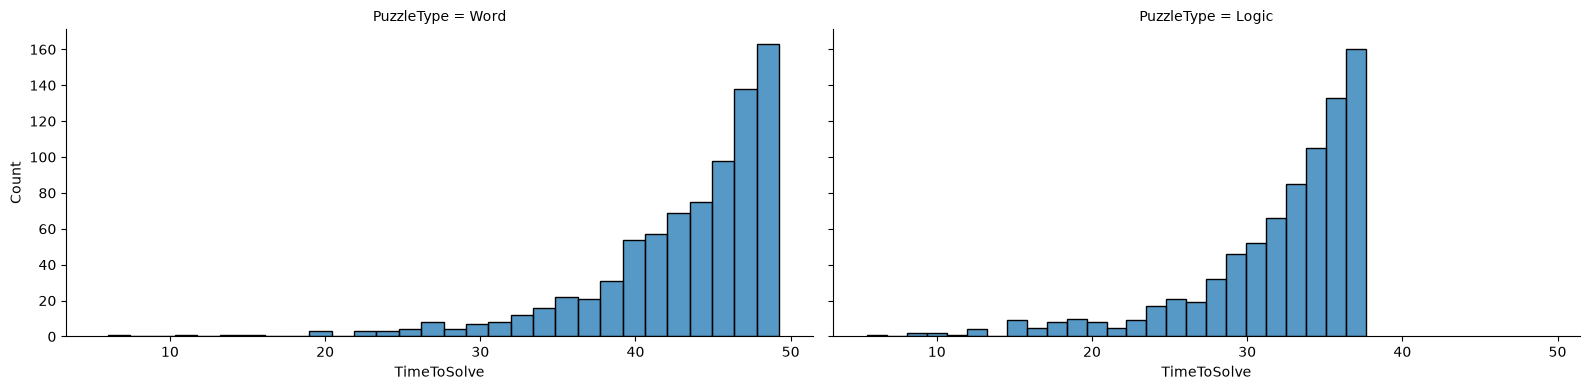

In [5]:
hist1 = sns.FacetGrid(game_data_np, col = "PuzzleType", height = 4, aspect=2)
hist1.map(sns.histplot,  "TimeToSolve")
plt.show()

the figure show that the normality of distribution is not respected.

instead of use ttest we will __wilcoxon-Mann-whitney__ test:

In [6]:
group_np_w= game_data_np[game_data_np["PuzzleType"] == "Word"]["TimeToSolve"]
group_np_l = game_data_np[game_data_np["PuzzleType"] == "Logic"]["TimeToSolve"]
mwu_results = pg.mwu(group_np_w, group_np_l, alternative= "two-sided")
print(mwu_results)

        U_val alternative          p_val       RBC      CLES
MWU  592183.5   two-sided  1.070864e-190  0.850573  0.925287


p value is less than 0.05 so time to solve puzzle word is diffrent from time to solve puzzle logic  
RBC the diiferent effect is strong

__non parametric test 2:__  
test if experience rating is independant from puzzle type.

In [7]:
f_table_np = pd.crosstab(game_data_np["PuzzleType"], game_data_np["isFun"])
print(f_table_np)
from scipy.stats import fisher_exact
odds_ratio, p_value = fisher_exact(f_table_np)
print(f"Odds Ratio: {odds_ratio}, P-Value: {p_value}")

isFun        No  Yes
PuzzleType          
Logic       477  323
Word        248  552
Odds Ratio: 3.287026865075402, P-Value: 8.949392701952381e-31


p value is less than 0.05 so experience rating is dependant from puzzle type

__power test:__

In [8]:
from statsmodels.stats.power import NormalIndPower
analysis = NormalIndPower()
power = analysis.power(effect_size= 3.28, nobs1=800, alpha =0.05, ratio=1)
print(f"power = {power}")

power = 1.0


__correlation (vitals.csv):__ 
correlation between height and weight.

__sample size:__

In [9]:
required_sample_size =pg.power_corr(r=0.4, power=0.8, alpha =0.05)
print(f"required_sample_size = {required_sample_size}")

required_sample_size = 45.91615155711663


__assumption verfication:__

__1- Linearity of veriables:__

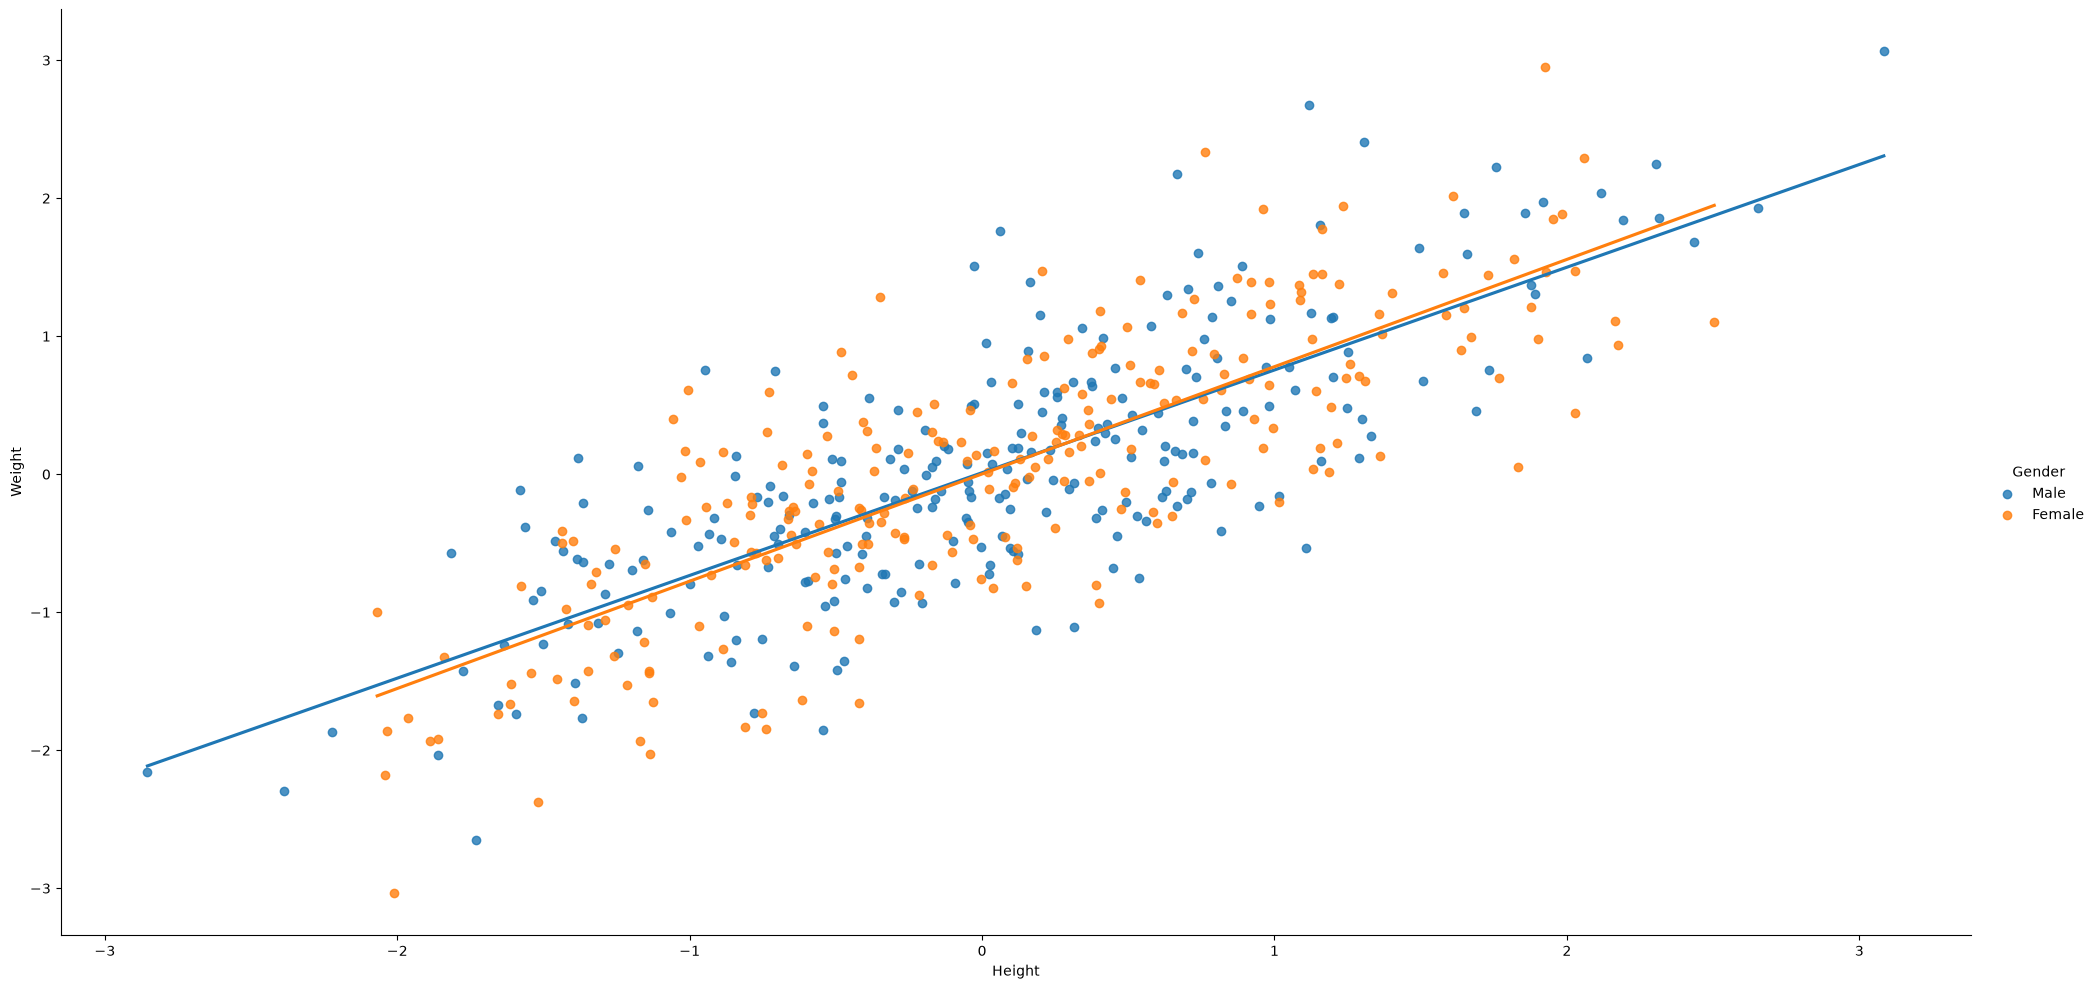

In [12]:
sns.lmplot(data = vitals, x = "Height", y = "Weight", hue = "Gender", ci = None, height = 10, aspect = 2)
plt.show()

__2- normality of variable:__

In [13]:
from scipy import stats
statistic, p_value_h = stats.shapiro(vitals["Height"])
print(f"p_value_h = {p_value_h}")
statistic, p_value_w = stats.shapiro(vitals["Weight"])
print(f"p_value_w = {p_value_w}")

p_value_h = 0.40052982873139964
p_value_w = 0.39966847050371157


the Height and Weight are normaly distributed

__correlation 1 ( without gender):__

In [14]:
result = pg.corr(x = vitals["Height"], y = vitals["Weight"], method = "pearson")
print(result)

           n         r          CI95          p_val        BF10  power
pearson  500  0.786131  [0.75, 0.82]  3.893862e-106  2.509e+102    1.0


__correlation 2 ( with gender):__

In [15]:
vitals_m = vitals[vitals["Gender"] == "Male"]
result_m = pg.corr(x = vitals_m["Height"], y = vitals_m["Weight"], method = "pearson")
print(result_m)


           n         r          CI95         p_val       BF10  power
pearson  252  0.773835  [0.72, 0.82]  1.698483e-51  1.223e+48    1.0


__Power test:__

In [16]:
power = pg.power_corr(r=0.79, n= 500, alpha =0.05)
print(f"power = {power}")

power = 1.0


__non parametric test (correlation) (spearman rest):__

__required sample:__

In [17]:
required_sample_size =pg.power_corr(r=0.3, power=0.8, alpha =0.05)
print(f"required_sample_size = {required_sample_size}") 

required_sample_size = 84.07363774429605


__correlation test:__

In [18]:
corr = pg.corr(x = vitals["Height"], y = vitals["Weight"], method = "spearman")
print(corr)

            n         r         CI95         p_val  power
spearman  500  0.770849  [0.73, 0.8]  1.358637e-99    1.0


__Power test:__

In [20]:
power = pg.power_corr(r=0.77, n= 500, alpha =0.05)
print(f"power = {power}")

power = 1.0
